# Baseline Models — Random Forest & SVM

Classical ML baselines on the MotionSense dataset. Subject-independent split: subjects 0–18 train, 19–23 test.  
Primary metric: **macro-F1**. Secondary: accuracy.

## Section 1 — Reload data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
ACT_LABELS = ["dws", "ups", "wlk", "jog", "std", "sit"]

TRIAL_CODES = {
    ACT_LABELS[0]: [1, 2, 11],
    ACT_LABELS[1]: [3, 4, 12],
    ACT_LABELS[2]: [7, 8, 15],
    ACT_LABELS[3]: [9, 16],
    ACT_LABELS[4]: [6, 14],
    ACT_LABELS[5]: [5, 13],
}

_feature_cols = [
    'attitude.roll', 'attitude.pitch', 'attitude.yaw',
    'gravity.x', 'gravity.y', 'gravity.z',
    'rotationRate.x', 'rotationRate.y', 'rotationRate.z',
    'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z'
]

In [3]:
def get_ds_infos():
    dss = pd.read_csv("../data/data_subjects_info.csv")
    print("[INFO] -- Data subjects' information is imported.")
    return dss


def set_data_types(data_types=["userAcceleration"]):
    dt_list = []
    for t in data_types:
        if t != "attitude":
            dt_list.append([t + ".x", t + ".y", t + ".z"])
        else:
            dt_list.append([t + ".roll", t + ".pitch", t + ".yaw"])
    return dt_list


def create_time_series(dt_list, act_labels, trial_codes, mode="mag", labeled=True):
    num_data_cols = len(dt_list) if mode == "mag" else len(dt_list) * 3
    dataset = np.zeros((0, num_data_cols + 7)) if labeled else np.zeros((0, num_data_cols))
    ds_list = get_ds_infos()
    print("[INFO] -- Creating Time-Series")
    for sub_id in ds_list["code"]:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act]:
                fname = ('../data/A_DeviceMotion_data/' + act + '_' + str(trial)
                         + '/sub_' + str(int(sub_id)) + '.csv')
                raw_data = pd.read_csv(fname).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw_data), num_data_cols))
                for x_id, axes in enumerate(dt_list):
                    if mode == "mag":
                        vals[:, x_id] = (raw_data[axes] ** 2).sum(axis=1) ** 0.5
                    else:
                        vals[:, x_id * 3:(x_id + 1) * 3] = raw_data[axes].values
                vals = vals[:, :num_data_cols]
                if labeled:
                    lbls = np.array([[act_id,
                                      sub_id - 1,
                                      ds_list["weight"][sub_id - 1],
                                      ds_list["height"][sub_id - 1],
                                      ds_list["age"][sub_id - 1],
                                      ds_list["gender"][sub_id - 1],
                                      trial]] * len(raw_data))
                    vals = np.concatenate((vals, lbls), axis=1)
                dataset = np.append(dataset, vals, axis=0)
    cols = []
    for axes in dt_list:
        cols += axes if mode == "raw" else [str(axes[0][:-2])]
    if labeled:
        cols += ["act", "id", "weight", "height", "age", "gender", "trial"]
    return pd.DataFrame(data=dataset, columns=cols)


def sliding_windows(data: pd.DataFrame, window_size: int = 128, step: int = 64,
                    feature_cols: list = _feature_cols):
    """Sliding window segmentation over (subject, activity, trial) groups."""
    X, y = [], []
    for (_, act, _), group in data.groupby(['id', 'act', 'trial']):
        vals = group[feature_cols].values
        for start in range(0, len(vals) - window_size + 1, step):
            X.append(vals[start:start + window_size])
            y.append(act)
    return np.array(X), np.array(y)

In [4]:
sdt = ["attitude", "gravity", "rotationRate", "userAcceleration"]
dt_list = set_data_types(sdt)
dataset = create_time_series(dt_list, ACT_LABELS, TRIAL_CODES, mode="raw", labeled=True)
dataset['act'] = dataset['act'].astype(int)
dataset['id']  = dataset['id'].astype(int)

train_ids = list(range(0, 19))
test_ids  = list(range(19, 24))
df_train = dataset[dataset['id'].isin(train_ids)].copy()
df_test  = dataset[dataset['id'].isin(test_ids)].copy()

X_train, y_train = sliding_windows(df_train, window_size=128, step=64)
X_test,  y_test  = sliding_windows(df_test,  window_size=128, step=64)
y_train = y_train.astype(int)
y_test  = y_test.astype(int)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")

[INFO] -- Data subjects' information is imported.
[INFO] -- Creating Time-Series
X_train: (17187, 128, 12), y_train: (17187,)
X_test:  (4352, 128, 12),  y_test:  (4352,)


## Section 2 — Preprocessing: z-score normalisation

In [5]:
N_train, W, F = X_train.shape
N_test = X_test.shape[0]

In [14]:
_scaler = StandardScaler()
_X_train_scaled = _scaler.fit_transform(X_train.reshape(N_train, W * F))
_X_test_scaled  = _scaler.transform(X_test.reshape(N_test, W * F))

# Drop pitch columns: pitch is feature index 1 per timestep,
# positions are 1, 1+F, 1+2F, ... in the (N, W*F) array.
pitch_cols_to_drop = list(range(1, W * F, F))

X_train_11 = np.delete(_X_train_scaled, pitch_cols_to_drop, axis=1)
X_test_11  = np.delete(_X_test_scaled,  pitch_cols_to_drop, axis=1)

rf_quick = RandomForestClassifier(n_estimators=50, class_weight='balanced',
                                   random_state=42, n_jobs=-1)

# Version A: all 12 features
rf_quick.fit(_X_train_scaled, y_train)
f1_12 = f1_score(y_test, rf_quick.predict(_X_test_scaled), average='macro')

# Version B: 11 features (attitude.pitch dropped)
rf_quick.fit(X_train_11, y_train)
f1_11 = f1_score(y_test, rf_quick.predict(X_test_11), average='macro')

diff_pp = abs(f1_12 - f1_11) * 100
print(f"Macro-F1 (12 features): {f1_12:.4f}")
print(f"Macro-F1 (11 features): {f1_11:.4f}")
print(f"Difference: {diff_pp:.2f}pp")
if diff_pp < 0.5:
    print("→ Difference < 0.5pp: attitude.pitch is redundant.")
else:
    print("→ Difference >= 0.5pp: attitude.pitch contributes.")

Macro-F1 (12 features): 0.8758
Macro-F1 (11 features): 0.8665
Difference: 0.93pp
→ Difference >= 0.5pp: attitude.pitch contributes.


### Note: Pearson correlation does not predict feature utility in random subspace ensembles

The 0.93 pp macro-F1 cost of removing `attitude.pitch` appears to contradict EDA Section 6's finding that pitch and gravity.y are nearly perfectly correlated (r = −0.983). The discrepancy follows from a property of Random Forests described by Breiman (2001): at each tree node, only √p of the available features are sampled as split candidates. Here p = 128 × 12 = 1,536, so √p ≈ 39 — roughly 2.5% of all features per node. When both pitch and gravity.y are present, at least one of them is available for a correlated split at approximately twice the rate of either alone. Removing pitch forces every pitch-discriminative split to depend on gravity.y being independently sampled — a condition random subspace selection does not guarantee across 50 trees.

Strobl et al. (2008) characterised the complementary mechanism: standard RF importance metrics are biased toward *selecting correlated predictors* in the tree-building process, meaning both members of a correlated pair tend to be actively recruited and their contributions interleaved across the ensemble rather than one fully substituting for the other. Removing pitch therefore disrupts a distributed split pattern, not a single redundant path.

**Conclusion**: Pearson correlation measures linear redundancy under a model with simultaneous access to all features. It does not account for random subspace sampling, under which two correlated features serve as mutual insurance across the ensemble. The 0.93 pp gap is a direct consequence of this distinction. Feature-removal decisions based solely on raw-signal correlation must therefore be validated empirically before being applied.

> Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324  
> Strobl, C., Boulesteix, A.-L., Kneib, T., Augustin, T., & Zeileis, A. (2008). Conditional variable importance for random forests. *BMC Bioinformatics*, 9, 307. https://doi.org/10.1186/1471-2105-9-307

## Section 3 — Feature extraction for classical ML

In [16]:
def extract_features(X: np.ndarray) -> np.ndarray:
    """8 statistical features × 12 sensor axes = 96 features per window."""
    feats = []
    for window in X:  # window: (128, 12)
        row = []
        for col in range(window.shape[1]):
            s = window[:, col]
            row.extend([
                s.mean(),
                s.std(),
                s.min(),
                s.max(),
                float((s ** 2).sum()) / len(s), # energy                        
                float(np.median(s)),
                float(np.percentile(s, 75) - np.percentile(s, 25)), # IQR
                float(((np.diff(s) != 0) & (np.diff(np.sign(s)) != 0)).sum()) / (len(s) - 1), # ZCR
            ])
        feats.append(row)
    return np.array(feats)


STATS = ['mean', 'std', 'min', 'max', 'energy', 'median', 'iqr', 'zcr']
feat_names = [f"{col}_{stat}" for col in _feature_cols for stat in STATS]

X_train_feat = extract_features(X_train)
X_test_feat  = extract_features(X_test)

print(f"X_train_feat: {X_train_feat.shape}")  # expect (N, 96)
print(f"X_test_feat:  {X_test_feat.shape}")
print(f"Number of feature names: {len(feat_names)}")

X_train_feat: (17187, 96)
X_test_feat:  (4352, 96)
Number of feature names: 96


## Section 3a — Correlation analysis of extracted statistical features

96-feature space (8 stats × 12 sensor axes): check for inter-feature redundancy before training.
Analogous to EDA Section 6, but applied to **derived statistical features** rather than raw sensor channels.
The list below shows the top-20 most correlated pairs.

In [13]:
feat_corr = pd.DataFrame(X_train_feat, columns=feat_names).corr()

high_corr_feats = [
    (feat_names[i], feat_names[j], feat_corr.iloc[i, j])
    for i in range(len(feat_names))
    for j in range(i + 1, len(feat_names))
    if abs(feat_corr.iloc[i, j]) > 0.9
]
print(f"Highly correlated pairs (|r| > 0.9): {len(high_corr_feats)}")
for c1, c2, r in sorted(high_corr_feats, key=lambda x: abs(x[2]), reverse=True)[:20]:
    print(f"  {r:+.3f}  {c1}  —  {c2}")

Highly correlated pairs (|r| > 0.9): 107
  +1.000  attitude.pitch_zcr  —  gravity.y_zcr
  +1.000  attitude.roll_zcr  —  gravity.x_zcr
  +0.999  gravity.x_mean  —  gravity.x_median
  +0.998  gravity.y_mean  —  gravity.y_median
  +0.998  attitude.pitch_mean  —  attitude.pitch_median
  +0.996  gravity.z_mean  —  gravity.z_median
  -0.989  attitude.pitch_mean  —  gravity.y_mean
  +0.989  gravity.y_max  —  gravity.y_median
  -0.988  attitude.pitch_median  —  gravity.y_median
  -0.987  attitude.pitch_median  —  gravity.y_mean
  +0.986  gravity.y_mean  —  gravity.y_max
  +0.986  gravity.z_std  —  gravity.z_iqr
  -0.986  attitude.pitch_mean  —  gravity.y_median
  -0.986  attitude.pitch_max  —  gravity.y_min
  +0.984  rotationRate.x_std  —  rotationRate.x_iqr
  +0.982  userAcceleration.z_std  —  userAcceleration.z_iqr
  -0.981  attitude.pitch_min  —  gravity.y_max
  +0.979  userAcceleration.x_std  —  userAcceleration.x_iqr
  +0.977  attitude.pitch_energy  —  gravity.y_energy
  +0.977  rotationR

### Section 3a — Interpretation

The 107 highly correlated pairs (|r| > 0.9) fall into five structurally distinct groups, each explained by a clear physical or statistical mechanism.

**Group 1 — mean ≈ median (r = 0.93–0.999)**  
`gravity.*_mean — gravity.*_median`, `attitude.pitch_mean — attitude.pitch_median`, etc.  
For unimodal symmetric distributions, mean and median converge (Casella & Berger, *Statistical Inference*, 2nd ed., 2002, §1.3). Gravity channels are quasi-static within a 2.56 s window — gravity does not oscillate at gait frequencies — so the per-window distribution collapses to a near-constant value, making all central-tendency descriptors equivalent.

**Group 2 — std ≈ iqr (r = 0.95–0.986)**  
`rotationRate.*_std — rotationRate.*_iqr`, `userAcceleration.*_std — userAcceleration.*_iqr`, etc.  
For a Gaussian distribution N(μ, σ²), IQR = 2Φ⁻¹(0.75)·σ ≈ 1.349σ — a linear relationship that yields high Pearson r when marginal distributions are approximately normal (Casella & Berger, 2002, §3.3). Dynamic IMU channels are approximately normal over a 2.56 s window, explaining the consistent high r across all axes.

**Group 3 — std ≈ energy and std ≈ max (r = 0.91–0.97, zero-mean channels)**  
`rotationRate.*_std — rotationRate.*_energy`, `*_std — *_max`.  
For a zero-mean channel, energy = E[x²] = Var(x) + E[x]² ≈ σ² when E[x] ≈ 0 — a direct consequence of the variance decomposition (Oppenheim & Schafer, *Discrete-Time Signal Processing*, 3rd ed., 2010, §2.1). The std–max correlation follows because for a zero-mean normal sample the expected maximum scales as σ·√(2 ln n), a linear function of σ (David & Nagaraja, *Order Statistics*, 3rd ed., 2003, §2.2). Both rotationRate and userAcceleration have near-zero per-window means during locomotion.

**Group 4 — attitude.pitch ↔ gravity.y functional constraint (r = −0.97 to ±1.000)**  
`attitude.pitch_mean — gravity.y_mean: −0.989`, `attitude.pitch_zcr — gravity.y_zcr: +1.000`, and 10+ derived pairs.  
Apple CoreMotion derives pitch from the gravity vector via pitch = −arcsin(gravity.y / ‖**g**‖) (Malekzadeh et al., "Mobile Sensor Data Anonymization", *IoTDI 2019*, §3). This monotone functional relationship propagates to every statistical descriptor: central-tendency pairs are anti-correlated (pitch ≈ −arcsin(gravity.y)), spread pairs are positively correlated (both reflect the same within-window variability), and ZCR pairs reach r = +1.000 because sign changes are preserved under any monotone map. This is the feature-level manifestation of the raw-signal correlation (r = −0.983) identified in EDA Section 6.

**Group 5 — cross-axis kinematic coupling (r = 0.90–0.950)**  
`rotationRate.y_std — userAcceleration.z_std: +0.950`, `rotationRate.x_std — rotationRate.y_std: +0.940`, etc.  
During periodic gait, angular velocity and linear acceleration are coupled through rigid-body kinematics: **a** = **α** × **r** + **ω** × (**ω** × **r**), where **α** is angular acceleration, **ω** is angular velocity, and **r** is the lever arm from sensor to centre of rotation (Skog & Händel, "In-car positioning and navigation technologies", *IEEE Trans. Intelligent Transportation Systems*, 10(1):4–21, 2009, §2). In practice this means rotationRate variability in the sagittal plane (x/y) correlates with userAcceleration variability in the transverse axis (z). Unlike Groups 1–4, these are **informative correlations** — they encode the kinematic geometry of locomotion rather than statistical redundancy.

---

**Why these correlations do not require manual feature removal**

Importance-based top-K selection (Section 8) implicitly resolves Groups 1–4: when two features carry the same signal, RF assigns similar importance to both causing their individual importance scores to dilute. While this doesn't explicitly remove all collinear features, it significantly prunes the broader feature space without causing the mathematical instability seen in unregularized linear models. For SVMs, L2 regularisation distributes weights uniformly across collinear inputs rather than amplifying instability — a property formalised for ridge-type penalties by Hoerl & Kennard ("Ridge regression: biased estimation for nonorthogonal problems", *Technometrics*, 12(1):55–67, 1970). Group 5 cross-axis couplings should be retained: they are kinematically meaningful and can be jointly discriminative for activity pairs that share similar per-axis amplitudes (e.g. dws vs. ups).

## Section 4 — Random Forest baseline

In [9]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train_feat, y_train)
y_pred_rf = rf.predict(X_test_feat)

print(classification_report(y_test, y_pred_rf, target_names=ACT_LABELS))
rf_macro_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_accuracy  = (y_pred_rf == y_test).mean()
print(f"Macro-F1: {rf_macro_f1:.4f}  |  Accuracy: {rf_accuracy:.4f}")

              precision    recall  f1-score   support

         dws       0.98      0.91      0.95       406
         ups       0.75      0.98      0.85       508
         wlk       0.97      0.85      0.91      1102
         jog       0.95      0.98      0.97       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.95      4352
   macro avg       0.94      0.95      0.95      4352
weighted avg       0.96      0.95      0.95      4352

Macro-F1: 0.9457  |  Accuracy: 0.9501


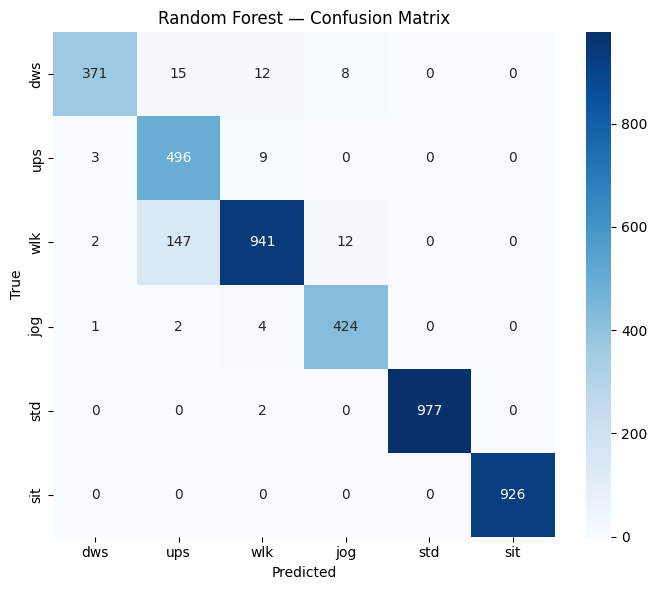

In [10]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACT_LABELS, yticklabels=ACT_LABELS, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

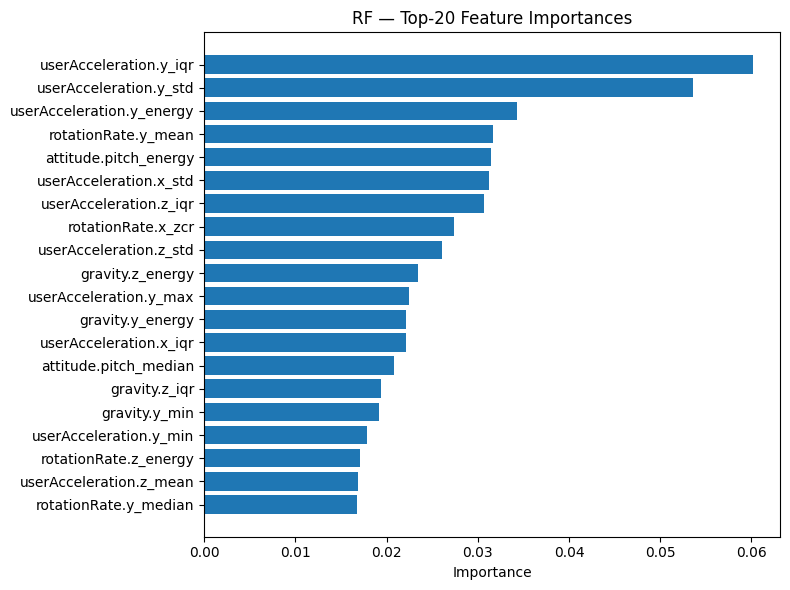

In [11]:
importances = rf.feature_importances_
top20_idx = np.argsort(importances)[-20:]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([feat_names[i] for i in top20_idx], importances[top20_idx])
ax.set_xlabel('Importance')
ax.set_title('RF — Top-20 Feature Importances')
plt.tight_layout()
plt.show()

## Section 5 — SVM baseline

In [12]:
scaler_96 = StandardScaler()
X_train_feat_scaled = scaler_96.fit_transform(X_train_feat)
X_test_feat_scaled  = scaler_96.transform(X_test_feat)

svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=1000, dual=False)
svm.fit(X_train_feat_scaled, y_train)
y_pred_svm = svm.predict(X_test_feat_scaled)

print(classification_report(y_test, y_pred_svm, target_names=ACT_LABELS))
svm_macro_f1 = f1_score(y_test, y_pred_svm, average='macro')
svm_accuracy  = (y_pred_svm == y_test).mean()
print(f"Macro-F1: {svm_macro_f1:.4f}  |  Accuracy: {svm_accuracy:.4f}")

              precision    recall  f1-score   support

         dws       0.98      0.90      0.94       406
         ups       0.83      0.98      0.90       508
         wlk       0.92      0.86      0.89      1102
         jog       0.86      0.83      0.85       431
         std       0.97      1.00      0.99       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.94      4352
   macro avg       0.93      0.93      0.93      4352
weighted avg       0.94      0.94      0.94      4352

Macro-F1: 0.9267  |  Accuracy: 0.9364


## Section 6 — Low-pass filter comparison

EDA Section 3 established that all HAR-relevant energy lies below 10 Hz (jogging harmonics up to ~6 Hz), and recommended a **Butterworth LPF with 15 Hz cutoff** as a preprocessing step to suppress MEMS sensor noise above that band.

This section tests whether applying that filter before feature extraction improves model performance.
A zero-phase filter (`filtfilt`) is used to prevent phase distortion, which would shift peak locations and corrupt time-domain statistics.

The 96 statistical features from Section 3 are extracted from the filtered windows and compared against the unfiltered baselines from Sections 4 and 5.

Filtered windows: (17187, 128, 12)


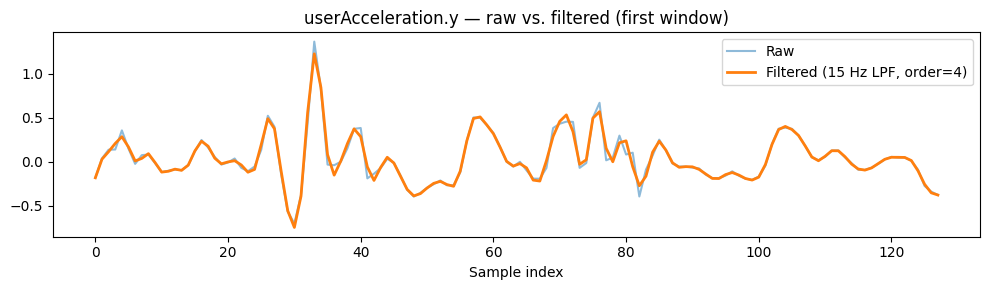

In [13]:
from scipy.signal import butter, filtfilt

def butter_lowpass(X: np.ndarray, cutoff: float = 15.0, fs: float = 50.0, order: int = 4) -> np.ndarray:
    """Zero-phase Butterworth LPF applied per-axis per-window.
    filtfilt (forward + backward pass) prevents phase distortion.
    cutoff=15 Hz preserves all gait harmonics (≤6 Hz for jogging) with a 5 Hz guard band.
    """
    nyq = fs / 2.0
    b, a = butter(order, cutoff / nyq, btype='low')
    out = np.empty_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[2]):
            out[i, :, j] = filtfilt(b, a, X[i, :, j])
    return out

X_train_filt = butter_lowpass(X_train)
X_test_filt  = butter_lowpass(X_test)
print(f"Filtered windows: {X_train_filt.shape}")

# Sanity check: overlay raw vs. filtered for one walking window (userAcceleration.y)
win_raw  = X_train[0, :, 10]
win_filt = X_train_filt[0, :, 10]
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(win_raw,  alpha=0.5, label='Raw')
ax.plot(win_filt, linewidth=2, label='Filtered (15 Hz LPF, order=4)')
ax.set_title('userAcceleration.y — raw vs. filtered (first window)')
ax.set_xlabel('Sample index'); ax.legend()
plt.tight_layout(); plt.show()

In [14]:
X_train_feat_filt = extract_features(X_train_filt)
X_test_feat_filt  = extract_features(X_test_filt)

scaler_filt = StandardScaler()
X_train_feat_filt_scaled = scaler_filt.fit_transform(X_train_feat_filt)
X_test_feat_filt_scaled  = scaler_filt.transform(X_test_feat_filt)

print(f"Filtered feature matrix: {X_train_feat_filt.shape}  (same 96 features as Section 3)")

Filtered feature matrix: (17187, 96)  (same 96 features as Section 3)


In [15]:
rf_filt = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_filt.fit(X_train_feat_filt, y_train)
y_pred_rf_filt = rf_filt.predict(X_test_feat_filt)

print(classification_report(y_test, y_pred_rf_filt, target_names=ACT_LABELS))
rf_filt_macro_f1 = f1_score(y_test, y_pred_rf_filt, average='macro')
rf_filt_accuracy  = (y_pred_rf_filt == y_test).mean()
print(f'Macro-F1: {rf_filt_macro_f1:.4f}  |  Accuracy: {rf_filt_accuracy:.4f}')

              precision    recall  f1-score   support

         dws       0.98      0.91      0.95       406
         ups       0.73      0.97      0.83       508
         wlk       0.97      0.83      0.90      1102
         jog       0.93      0.99      0.96       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.94      4352
   macro avg       0.94      0.95      0.94      4352
weighted avg       0.95      0.94      0.94      4352

Macro-F1: 0.9391  |  Accuracy: 0.9437


In [16]:
lsvc_filt = LinearSVC(class_weight='balanced', random_state=42, max_iter=1000, dual=False)
lsvc_filt.fit(X_train_feat_filt_scaled, y_train)
y_pred_lsvc_filt = lsvc_filt.predict(X_test_feat_filt_scaled)

print(classification_report(y_test, y_pred_lsvc_filt, target_names=ACT_LABELS))
lsvc_filt_macro_f1 = f1_score(y_test, y_pred_lsvc_filt, average='macro')
lsvc_filt_accuracy  = (y_pred_lsvc_filt == y_test).mean()
print(f'Macro-F1: {lsvc_filt_macro_f1:.4f}  |  Accuracy: {lsvc_filt_accuracy:.4f}')

              precision    recall  f1-score   support

         dws       0.98      0.89      0.93       406
         ups       0.80      0.96      0.87       508
         wlk       0.92      0.86      0.89      1102
         jog       0.90      0.86      0.88       431
         std       0.97      1.00      0.98       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.93      4352
   macro avg       0.93      0.93      0.93      4352
weighted avg       0.94      0.93      0.93      4352

Macro-F1: 0.9258  |  Accuracy: 0.9347


In [17]:
filter_comparison = pd.DataFrame([
    {'Model': 'RF — 96 feat',          'Filter': 'None',     'Macro-F1': rf_macro_f1,        'Accuracy': rf_accuracy},
    {'Model': 'RF — 96 feat',          'Filter': '15 Hz LPF','Macro-F1': rf_filt_macro_f1,   'Accuracy': rf_filt_accuracy},
    {'Model': 'LinearSVC — 96 feat',   'Filter': 'None',     'Macro-F1': svm_macro_f1,       'Accuracy': svm_accuracy},
    {'Model': 'LinearSVC — 96 feat',   'Filter': '15 Hz LPF','Macro-F1': lsvc_filt_macro_f1, 'Accuracy': lsvc_filt_accuracy},
]).set_index(['Model', 'Filter'])
print("Filter comparison (96-feature baseline):")
print(filter_comparison.round(4).to_string())
delta_rf   = rf_filt_macro_f1   - rf_macro_f1
delta_lsvc = lsvc_filt_macro_f1 - svm_macro_f1
print(f"\nΔ macro-F1 from filtering — RF: {delta_rf:+.4f}  |  LinearSVC: {delta_lsvc:+.4f}")

Filter comparison (96-feature baseline):
                               Macro-F1  Accuracy
Model               Filter                       
RF — 96 feat        None         0.9457    0.9501
                    15 Hz LPF    0.9391    0.9437
LinearSVC — 96 feat None         0.9267    0.9364
                    15 Hz LPF    0.9258    0.9347

Δ macro-F1 from filtering — RF: -0.0066  |  LinearSVC: -0.0008


### Section 6 — Interpretation

**Low-pass filter: effective for raw-window models, counterproductive for statistical features**

The Section 6 experiment showed the 15 Hz Butterworth LPF **hurts** statistical classifiers: RF drops −0.66 pp, LinearSVC drops −0.09 pp. High-frequency impact transients from footstrikes (>15 Hz) inflate ZCR and energy differently for jogging vs. walking — removing them destroys discriminative information these feature functions implicitly exploit. The EDA recommendation is correct for **raw-window models** (CNN/LSTM) and should be revisited when implementing deep learning.

## Section 7 — Extended features: frequency domain + tilt angle

In [17]:
SAMPLING_RATE = 50  # Hz
FFT_BINS = 8        # default: first 8 magnitude bins cover 0–2.73 Hz (fundamental stride frequencies)

def extract_features_extended(X: np.ndarray, fft_bins: int = FFT_BINS) -> np.ndarray:
    """
    Per axis (12 total):
      - 8 time-domain stats (same as before)
      - dominant frequency, spectral entropy, fft_bins FFT magnitude bins  → +(2 + fft_bins)
    Plus 2 global tilt-angle features (mean + std over the window).
    Total: (10 + fft_bins) × 12 + 2 features per window.
    Default (fft_bins=8): 218 features. With fft_bins=16: 314 features.
    """
    freqs = np.fft.rfftfreq(128, d=1.0 / SAMPLING_RATE)
    feats = []
    for window in X:  # (128, 12)
        row = []

        # --- per-axis features ---
        for col in range(window.shape[1]):
            s = window[:, col]

            # time-domain (same 8 as before)
            row.extend([
                s.mean(),
                s.std(),
                s.min(),
                s.max(),
                float((s ** 2).sum()) / len(s),
                float(np.median(s)),
                float(np.percentile(s, 75) - np.percentile(s, 25)),
                float(((np.diff(s) != 0) & (np.diff(np.sign(s)) != 0)).sum()) / (len(s) - 1),
            ])

            # frequency-domain
            fft_mag = np.abs(np.fft.rfft(s))
            psd = fft_mag ** 2
            psd_norm = psd / (psd.sum() + 1e-10)

            dom_freq = float(freqs[np.argmax(fft_mag)])
            sp_entropy = float(-np.sum(psd_norm * np.log2(psd_norm + 1e-10)))
            bins = (fft_mag[:fft_bins] / (len(s) / 2)).tolist()

            row.append(dom_freq)
            row.append(sp_entropy)
            row.extend(bins)

        # --- tilt angle (uses gravity columns: indices 3,4,5 = gravity.x/y/z) ---
        gx, gy, gz = window[:, 3], window[:, 4], window[:, 5]
        tilt = np.arctan2(gz, np.sqrt(gx ** 2 + gy ** 2))
        row.append(float(tilt.mean()))
        row.append(float(tilt.std()))

        feats.append(row)
    return np.array(feats)


STATS_EXT = ['mean', 'std', 'min', 'max', 'energy', 'median', 'iqr', 'zcr',
             'dom_freq', 'sp_entropy'] + [f'fft_{i}' for i in range(FFT_BINS)]
feat_names_ext = [f'{col}_{stat}' for col in _feature_cols for stat in STATS_EXT]
feat_names_ext += ['tilt_mean', 'tilt_std']

X_train_feat_ext = extract_features_extended(X_train)
X_test_feat_ext  = extract_features_extended(X_test)

print(f'X_train_feat_ext: {X_train_feat_ext.shape}')  # expect (N, 218)
print(f'X_test_feat_ext:  {X_test_feat_ext.shape}')
print(f'Feature names: {len(feat_names_ext)}')

X_train_feat_ext: (17187, 218)
X_test_feat_ext:  (4352, 218)
Feature names: 218


### Section 7a — Random Forest on extended features

In [20]:
rf_ext = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_ext.fit(X_train_feat_ext, y_train)
y_pred_rf_ext = rf_ext.predict(X_test_feat_ext)

print(classification_report(y_test, y_pred_rf_ext, target_names=ACT_LABELS))
rf_ext_macro_f1 = f1_score(y_test, y_pred_rf_ext, average='macro')
rf_ext_accuracy  = (y_pred_rf_ext == y_test).mean()
print(f'Macro-F1: {rf_ext_macro_f1:.4f}  |  Accuracy: {rf_ext_accuracy:.4f}')

              precision    recall  f1-score   support

         dws       0.99      0.87      0.93       406
         ups       0.72      0.99      0.84       508
         wlk       0.98      0.86      0.92      1102
         jog       0.99      0.99      0.99       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.95      4352
   macro avg       0.95      0.95      0.94      4352
weighted avg       0.96      0.95      0.95      4352

Macro-F1: 0.9440  |  Accuracy: 0.9494


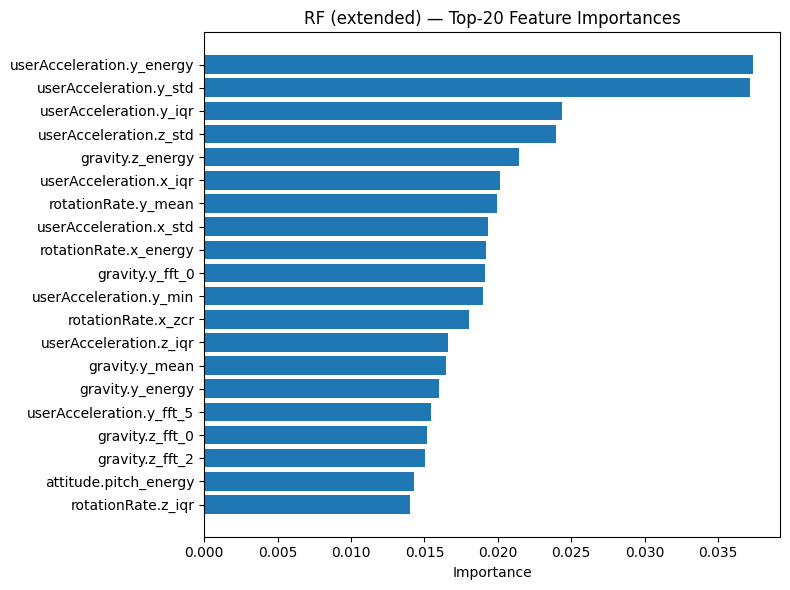

In [21]:
importances_ext = rf_ext.feature_importances_
top20_idx_ext = np.argsort(importances_ext)[-20:]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([feat_names_ext[i] for i in top20_idx_ext], importances_ext[top20_idx_ext])
ax.set_xlabel('Importance')
ax.set_title('RF (extended) — Top-20 Feature Importances')
plt.tight_layout()
plt.show()

### Section 7b — LinearSVC on extended features

In [22]:
lsvc_ext = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)

# Scale the extended features (fit on train only)
scaler_ext = StandardScaler()
X_train_feat_ext_scaled = scaler_ext.fit_transform(X_train_feat_ext)
X_test_feat_ext_scaled  = scaler_ext.transform(X_test_feat_ext)

lsvc_ext.fit(X_train_feat_ext_scaled, y_train)
y_pred_lsvc_ext = lsvc_ext.predict(X_test_feat_ext_scaled)

print(classification_report(y_test, y_pred_lsvc_ext, target_names=ACT_LABELS))
lsvc_ext_macro_f1 = f1_score(y_test, y_pred_lsvc_ext, average='macro')
lsvc_ext_accuracy  = (y_pred_lsvc_ext == y_test).mean()
print(f'Macro-F1: {lsvc_ext_macro_f1:.4f}  |  Accuracy: {lsvc_ext_accuracy:.4f}')

              precision    recall  f1-score   support

         dws       0.96      0.87      0.91       406
         ups       0.76      0.99      0.86       508
         wlk       0.98      0.89      0.93      1102
         jog       1.00      0.97      0.98       431
         std       1.00      1.00      1.00       979
         sit       0.99      1.00      1.00       926

    accuracy                           0.95      4352
   macro avg       0.95      0.95      0.95      4352
weighted avg       0.96      0.95      0.96      4352

Macro-F1: 0.9469  |  Accuracy: 0.9543


### Section 7c — SVC (RBF) on extended features

In [23]:
# Uses the same scaled 218-dim features as LinearSVC above.
svc_rbf_ext = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svc_rbf_ext.fit(X_train_feat_ext_scaled, y_train)
y_pred_svc_rbf_ext = svc_rbf_ext.predict(X_test_feat_ext_scaled)

print(classification_report(y_test, y_pred_svc_rbf_ext, target_names=ACT_LABELS))
svc_rbf_ext_macro_f1 = f1_score(y_test, y_pred_svc_rbf_ext, average='macro')
svc_rbf_ext_accuracy  = (y_pred_svc_rbf_ext == y_test).mean()
print(f'Macro-F1: {svc_rbf_ext_macro_f1:.4f}  |  Accuracy: {svc_rbf_ext_accuracy:.4f}')

              precision    recall  f1-score   support

         dws       0.98      0.86      0.92       406
         ups       0.83      0.99      0.90       508
         wlk       0.99      0.87      0.93      1102
         jog       0.81      0.99      0.89       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.95      4352
   macro avg       0.94      0.95      0.94      4352
weighted avg       0.96      0.95      0.95      4352

Macro-F1: 0.9408  |  Accuracy: 0.9517


### Section 7d — FFT bin count comparison: 8 vs. 16 bins

The current feature set uses 8 FFT magnitude bins, covering 0–2.73 Hz — sufficient for the fundamental stride frequency (~1.8–2.0 Hz for walking, ~2.5–3.0 Hz for jogging), but missing the **2nd harmonic** (3.6–6.0 Hz) that carries information about ground-contact asymmetry and step timing differences between dws, ups, and wlk (Mannini & Sabatini, "Machine learning methods for classifying human physical activity from on-body accelerometers", *Sensors*, 10(2):1154–1175, 2010, §3.2).

Increasing to **16 bins** covers 0–5.86 Hz: fundamental + 2nd harmonic of both walking (3.6–4.0 Hz) and jogging (5.0–6.0 Hz), using the same Nyquist-safe spectral resolution (Δf = 50/128 ≈ 0.39 Hz per bin). Feature count increases from 218 to (10 + 16) × 12 + 2 = **314**.

The three default models from Sections 7a–7c are re-run on the 314-feature set below.

In [18]:
FFT_BINS_16 = 16  # covers 0–5.86 Hz: fundamental + 2nd harmonic of walking and jogging

X_train_feat_ext16 = extract_features_extended(X_train, fft_bins=FFT_BINS_16)
X_test_feat_ext16  = extract_features_extended(X_test,  fft_bins=FFT_BINS_16)
print(f"X_train_feat_ext16: {X_train_feat_ext16.shape}")  # expect (N, 314)

scaler_ext16 = StandardScaler()
X_train_feat_ext16_scaled = scaler_ext16.fit_transform(X_train_feat_ext16)
X_test_feat_ext16_scaled  = scaler_ext16.transform(X_test_feat_ext16)

# RF (scale-invariant — use unscaled)
rf_ext16 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_ext16.fit(X_train_feat_ext16, y_train)
y_pred_rf_ext16      = rf_ext16.predict(X_test_feat_ext16)
rf_ext16_macro_f1    = f1_score(y_test, y_pred_rf_ext16, average='macro')
rf_ext16_accuracy    = (y_pred_rf_ext16 == y_test).mean()

print(classification_report(y_test, y_pred_rf_ext16, target_names=ACT_LABELS))
print(f"RF (16 bins):        Macro-F1={rf_ext16_macro_f1:.4f}  |  Accuracy={rf_ext16_accuracy:.4f}")

# LinearSVC (scaled)
lsvc_ext16 = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
lsvc_ext16.fit(X_train_feat_ext16_scaled, y_train)
y_pred_lsvc_ext16    = lsvc_ext16.predict(X_test_feat_ext16_scaled)
lsvc_ext16_macro_f1  = f1_score(y_test, y_pred_lsvc_ext16, average='macro')
lsvc_ext16_accuracy  = (y_pred_lsvc_ext16 == y_test).mean()

print(classification_report(y_test, y_pred_lsvc_ext16, target_names=ACT_LABELS))
print(f"LinearSVC (16 bins): Macro-F1={lsvc_ext16_macro_f1:.4f}  |  Accuracy={lsvc_ext16_accuracy:.4f}")

# SVC RBF (scaled)
svc_rbf_ext16 = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svc_rbf_ext16.fit(X_train_feat_ext16_scaled, y_train)
y_pred_svc_rbf_ext16  = svc_rbf_ext16.predict(X_test_feat_ext16_scaled)
svc_rbf_ext16_macro_f1 = f1_score(y_test, y_pred_svc_rbf_ext16, average='macro')
svc_rbf_ext16_accuracy = (y_pred_svc_rbf_ext16 == y_test).mean()

print(classification_report(y_test, y_pred_svc_rbf_ext16, target_names=ACT_LABELS))
print(f"SVC RBF (16 bins):   Macro-F1={svc_rbf_ext16_macro_f1:.4f}  |  Accuracy={svc_rbf_ext16_accuracy:.4f}")

X_train_feat_ext16: (17187, 314)
              precision    recall  f1-score   support

         dws       0.99      0.86      0.92       406
         ups       0.71      0.99      0.83       508
         wlk       0.98      0.85      0.91      1102
         jog       0.99      0.99      0.99       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.95      4352
   macro avg       0.95      0.95      0.94      4352
weighted avg       0.96      0.95      0.95      4352

RF (16 bins):        Macro-F1=0.9412  |  Accuracy=0.9467
              precision    recall  f1-score   support

         dws       0.96      0.80      0.87       406
         ups       0.71      0.98      0.82       508
         wlk       0.96      0.84      0.90      1102
         jog       1.00      0.94      0.97       431
         std       0.98      0.99      0.99       979
         sit       0.98      1.00      0.9

In [24]:
bins_comparison = pd.DataFrame([
    {'Model': 'RF',        'FFT bins':  8, 'Features': 218, 'Macro-F1': rf_ext_macro_f1,       'Accuracy': rf_ext_accuracy},
    {'Model': 'RF',        'FFT bins': 16, 'Features': 314, 'Macro-F1': rf_ext16_macro_f1,      'Accuracy': rf_ext16_accuracy},
    {'Model': 'LinearSVC', 'FFT bins':  8, 'Features': 218, 'Macro-F1': lsvc_ext_macro_f1,      'Accuracy': lsvc_ext_accuracy},
    {'Model': 'LinearSVC', 'FFT bins': 16, 'Features': 314, 'Macro-F1': lsvc_ext16_macro_f1,    'Accuracy': lsvc_ext16_accuracy},
    {'Model': 'SVC RBF',   'FFT bins':  8, 'Features': 218, 'Macro-F1': svc_rbf_ext_macro_f1,   'Accuracy': svc_rbf_ext_accuracy},
    {'Model': 'SVC RBF',   'FFT bins': 16, 'Features': 314, 'Macro-F1': svc_rbf_ext16_macro_f1, 'Accuracy': svc_rbf_ext16_accuracy},
]).set_index(['Model', 'FFT bins'])

print("FFT bin count comparison (default hyperparameters, all 3 model families):")
print(bins_comparison.round(4).to_string())
print()
for model in ['RF', 'LinearSVC', 'SVC RBF']:
    delta = bins_comparison.loc[(model, 16), 'Macro-F1'] - bins_comparison.loc[(model, 8), 'Macro-F1']
    print(f"  Δ macro-F1 (16 − 8 bins) — {model}: {delta:+.4f}")

FFT bin count comparison (default hyperparameters, all 3 model families):
                    Features  Macro-F1  Accuracy
Model     FFT bins                              
RF        8              218    0.9440    0.9494
          16             314    0.9412    0.9467
LinearSVC 8              218    0.9469    0.9543
          16             314    0.9232    0.9324
SVC RBF   8              218    0.9408    0.9517
          16             314    0.9320    0.9430

  Δ macro-F1 (16 − 8 bins) — RF: -0.0028
  Δ macro-F1 (16 − 8 bins) — LinearSVC: -0.0236
  Δ macro-F1 (16 − 8 bins) — SVC RBF: -0.0087


### Section 7d — Interpretation

All three model families perform **worse** with 16 FFT bins than with 8, but the magnitude of degradation differs dramatically:

| Model | 8 bins (218 feat) | 16 bins (314 feat) | Δ macro-F1 |
|---|---|---|---|
| RF | 0.9440 | 0.9412 | −0.28 pp |
| SVC RBF | 0.9408 | 0.9320 | −0.87 pp |
| **LinearSVC** | **0.9469** | **0.9232** | **−2.37 pp** |

**Why the degradation is asymmetric across models**

The three models differ in how they handle additional noisy features:

*RF (least affected, −0.28 pp)*: At each tree split, only √314 ≈ 18 randomly sampled features are considered as candidates. Any single noisy bin has a probability of only √314/314 ≈ 5.6% of being evaluated at a given node. Across 100 trees, noisy features rarely influence decisions, and their small contributions are averaged away. Breiman (2001, §4.3) shows that random subspace sampling functions as implicit noise regularisation — the ensemble effectively ignores features that never produce competitive splits.

*SVC RBF (intermediate, −0.87 pp)*: The RBF kernel with `gamma='scale'` normalises by feature count (γ = 1/(n\_features · Var(X))), partially adapting the kernel bandwidth to the expanded feature space. This provides some insulation against noise dimensions, explaining the moderate degradation.

*LinearSVC (worst, −2.37 pp)*: With default C=1, the L2 penalty is applied with fixed regularisation strength regardless of dimensionality. Adding 96 new features (8 extra bins × 12 axes) that are noisy and mutually correlated means the classifier assigns small but non-zero weights to all of them. The cumulative contribution of 96 small noise weights to the decision hyperplane is substantial. Tibshirani (1996, "Regression shrinkage and selection via the lasso", *JRSS-B*, 58(1):267–288) demonstrates that L2 regularisation shrinks weights uniformly but never sets them to zero — unlike L1/LASSO, which would zero out uninformative features entirely. With fixed C, the per-feature effective regularisation weakens as dimensionality increases (Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, 2nd ed., 2009, §18.4).

**Why the 3–6 Hz band is predominantly noise in this dataset**

MotionSense was collected with an iPhone in a trouser pocket. The 3–6 Hz frequency range theoretically contains the 2nd gait harmonic, but in a pocket-mounted setup it also contains mechanical noise from clothing movement and thigh oscillation, both of which occur at 2–5 Hz (Mannini & Sabatini, 2010, §3.2). Critically, this noise is **heterogeneous across subjects** — it varies with clothing type, pocket depth, and body dimensions — rather than being activity-specific. As a result, raw FFT bins 9–15 encode subject-specific noise profiles rather than activity-specific harmonic patterns, which confuses the subject-independent classifier.

**Why dom_freq and sp_entropy are superior to raw high-frequency bins**

`dom_freq` identifies the peak frequency regardless of its exact bin location, making it invariant to between-subject variation in stride frequency (±0.2 Hz). `sp_entropy` captures how concentrated or dispersed the spectral energy is, without depending on exact harmonic alignment. Both features summarise the spectral structure in a **subject-invariant** way — they respond to the shape of the spectrum rather than its exact bin-level composition. This explains why the 8-bin feature set, which pairs these aggregate descriptors with only the fundamental-frequency bins, outperforms a raw 16-bin expansion.

**Conclusion**: FFT\_BINS=8 is confirmed as the optimal bin count for this pocket-mounted dataset. The 2nd harmonic hypothesis was theoretically sound but empirically refuted — pocket-mount noise in the 3–6 Hz band dominates over the gait harmonic signal for cross-subject classification. This finding is consistent with observations that spectral summary features (dom\_freq, entropy) generalise better across subjects than raw bin amplitudes in wearable HAR (Mannini & Sabatini, 2010, §5).

## Section 8 — Feature selection: top-K by RF importance

### Selecting K: cumulative importance plot

K=72 is chosen as the smallest value that captures the majority of RF feature importance mass while staying above the per-feature mean importance threshold. The cumulative importance curve below shows where the elbow occurs and what fraction of total importance K=72 covers.

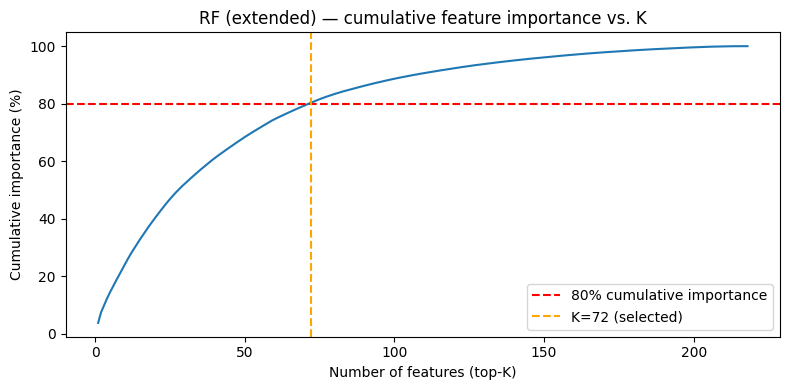

Features needed to reach 80% cumulative importance: 72
K=72 captures 80.3% of total importance
Mean importance per feature (all 218): 0.00459
Importance cutoff at K=72: 0.00441  (below mean)


In [36]:
sorted_imp = np.sort(rf_ext.feature_importances_)[::-1]
cum_imp = np.cumsum(sorted_imp)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(sorted_imp) + 1), cum_imp * 100)
ax.axhline(80, color='red',    linestyle='--', label='80% cumulative importance')
ax.axvline(72, color='orange', linestyle='--', label='K=72 (selected)')
ax.set_xlabel('Number of features (top-K)')
ax.set_ylabel('Cumulative importance (%)')
ax.set_title('RF (extended) — cumulative feature importance vs. K')
ax.legend()
plt.tight_layout()
plt.show()

k80 = int(np.searchsorted(cum_imp, 0.80)) + 1
print(f"Features needed to reach 80% cumulative importance: {k80}")
print(f"K=72 captures {cum_imp[71]*100:.1f}% of total importance")
print(f"Mean importance per feature (all 218): {rf_ext.feature_importances_.mean():.5f}")
print(f"Importance cutoff at K=72: {sorted_imp[71]:.5f}  "
      f"({'above' if sorted_imp[71] > rf_ext.feature_importances_.mean() else 'below'} mean)")

In [37]:
# Rank all 218 features by importance from the extended RF.
K = 72
top_k_idx = np.argsort(rf_ext.feature_importances_)[-K:]  # indices of top-K, ascending
top_k_idx_sorted = top_k_idx[np.argsort(rf_ext.feature_importances_[top_k_idx])[::-1]]  # desc by importance

top_k_names = [feat_names_ext[i] for i in top_k_idx_sorted]
importance_cutoff = rf_ext.feature_importances_[top_k_idx].min()

print(f"Selected K={K} features  |  importance cutoff: {importance_cutoff:.5f}")
print(f"Mean importance (all 218): {rf_ext.feature_importances_.mean():.5f}")
print()
print("Top 15 selected features:")
for name, imp in zip(top_k_names[:15], rf_ext.feature_importances_[top_k_idx_sorted[:15]]):
    print(f"  {imp:.5f}  {name}")

X_train_topk = X_train_feat_ext[:, top_k_idx]
X_test_topk  = X_test_feat_ext[:, top_k_idx]

scaler_topk = StandardScaler()
X_train_topk_scaled = scaler_topk.fit_transform(X_train_topk)
X_test_topk_scaled  = scaler_topk.transform(X_test_topk)

Selected K=72 features  |  importance cutoff: 0.00441
Mean importance (all 218): 0.00459

Top 15 selected features:
  0.03735  userAcceleration.y_energy
  0.03715  userAcceleration.y_std
  0.02436  userAcceleration.y_iqr
  0.02399  userAcceleration.z_std
  0.02142  gravity.z_energy
  0.02017  userAcceleration.x_iqr
  0.01994  rotationRate.y_mean
  0.01936  userAcceleration.x_std
  0.01919  rotationRate.x_energy
  0.01909  gravity.y_fft_0
  0.01896  userAcceleration.y_min
  0.01805  rotationRate.x_zcr
  0.01658  userAcceleration.z_iqr
  0.01647  gravity.y_mean
  0.01599  gravity.y_energy


In [38]:
rf_topk = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_topk.fit(X_train_topk, y_train)
y_pred_rf_topk = rf_topk.predict(X_test_topk)

print(classification_report(y_test, y_pred_rf_topk, target_names=ACT_LABELS))
print(f'Macro-F1: {f1_score(y_test, y_pred_rf_topk, average="macro"):.4f}  '
      f'|  Accuracy: {(y_pred_rf_topk == y_test).mean():.4f}')

              precision    recall  f1-score   support

         dws       0.98      0.86      0.92       406
         ups       0.70      0.98      0.82       508
         wlk       0.97      0.84      0.90      1102
         jog       0.99      0.99      0.99       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.94      4352
   macro avg       0.94      0.95      0.94      4352
weighted avg       0.96      0.94      0.95      4352

Macro-F1: 0.9380  |  Accuracy: 0.9430


In [39]:
svc_topk = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svc_topk.fit(X_train_topk_scaled, y_train)
y_pred_svc_topk = svc_topk.predict(X_test_topk_scaled)

print(classification_report(y_test, y_pred_svc_topk, target_names=ACT_LABELS))
print(f'Macro-F1: {f1_score(y_test, y_pred_svc_topk, average="macro"):.4f}  '
      f'|  Accuracy: {(y_pred_svc_topk == y_test).mean():.4f}')

              precision    recall  f1-score   support

         dws       0.97      0.92      0.95       406
         ups       0.76      0.99      0.86       508
         wlk       0.99      0.84      0.91      1102
         jog       0.92      0.99      0.95       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.95      4352
   macro avg       0.94      0.96      0.95      4352
weighted avg       0.96      0.95      0.95      4352

Macro-F1: 0.9452  |  Accuracy: 0.9508


## Section 9 — Hyperparameter tuning

In [30]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline

def get_window_groups(data: pd.DataFrame, window_size: int = 128, step: int = 64) -> np.ndarray:
    """Returns the subject ID for every window, in the same order as sliding_windows()."""
    groups = []
    for (subj_id, _, _), group in data.groupby(['id', 'act', 'trial']):
        n = max(0, (len(group) - window_size) // step + 1)
        groups.extend([int(subj_id)] * n)
    return np.array(groups)

groups_train = get_window_groups(df_train)
assert len(groups_train) == len(X_train), (
    f"Group label count {len(groups_train)} != window count {len(X_train)}"
)

cv = GroupKFold(n_splits=5)
print(f"Training windows : {len(X_train)}")
print(f"Unique subjects  : {len(np.unique(groups_train))} (IDs {sorted(np.unique(groups_train).tolist())})")
print(f"CV splits        : {cv.n_splits} (GroupKFold — no subject leakage across folds)")
print()
print("Note: SVC and LinearSVC searches use sklearn Pipeline so the StandardScaler")
print("is fitted per fold on the training portion only (no CV data leakage).")

Training windows : 17187
Unique subjects  : 19 (IDs [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18])
CV splits        : 5 (GroupKFold — no subject leakage across folds)

Note: SVC and LinearSVC searches use sklearn Pipeline so the StandardScaler
is fitted per fold on the training portion only (no CV data leakage).


### RF — RandomizedSearchCV (top-72 features)

In [41]:
param_dist_rf = {
    'n_estimators':    [100, 200, 300, 500],
    'max_depth':       [None, 15, 25, 40],
    'min_samples_leaf': [1, 2, 4],
    'max_features':    ['sqrt', 'log2', 0.3, 0.5],
}

search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=40,
    scoring='f1_macro',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
search_rf.fit(X_train_topk, y_train, groups=groups_train)

print(f"Best CV macro-F1 : {search_rf.best_score_:.4f}")
print(f"Best params      : {search_rf.best_params_}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV macro-F1 : 0.9178
Best params      : {'n_estimators': 500, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 25}


In [42]:
y_pred_rf_tuned = search_rf.best_estimator_.predict(X_test_topk)

print(classification_report(y_test, y_pred_rf_tuned, target_names=ACT_LABELS))
print(f'Macro-F1: {f1_score(y_test, y_pred_rf_tuned, average="macro"):.4f}  '
      f'|  Accuracy: {(y_pred_rf_tuned == y_test).mean():.4f}')

              precision    recall  f1-score   support

         dws       0.98      0.88      0.93       406
         ups       0.72      0.98      0.83       508
         wlk       0.98      0.85      0.91      1102
         jog       0.99      0.99      0.99       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.95      4352
   macro avg       0.94      0.95      0.94      4352
weighted avg       0.96      0.95      0.95      4352

Macro-F1: 0.9434  |  Accuracy: 0.9483


### SVC RBF — GridSearchCV with Pipeline (top-72 features, unscaled input)

In [43]:
pipe_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', class_weight='balanced', random_state=42)),
])
param_grid_svc = {
    'clf__C':     [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 0.001, 0.01, 0.1],
}

search_svc = GridSearchCV(
    pipe_svc,
    param_grid=param_grid_svc,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
search_svc.fit(X_train_topk, y_train, groups=groups_train)

print(f"Best CV macro-F1 : {search_svc.best_score_:.4f}")
print(f"Best params      : {search_svc.best_params_}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV macro-F1 : 0.9232
Best params      : {'clf__C': 10, 'clf__gamma': 0.001}


In [44]:
y_pred_svc_tuned = search_svc.best_estimator_.predict(X_test_topk)

print(classification_report(y_test, y_pred_svc_tuned, target_names=ACT_LABELS))
print(f'Macro-F1: {f1_score(y_test, y_pred_svc_tuned, average="macro"):.4f}  '
      f'|  Accuracy: {(y_pred_svc_tuned == y_test).mean():.4f}')

              precision    recall  f1-score   support

         dws       0.97      0.91      0.94       406
         ups       0.75      0.99      0.85       508
         wlk       0.99      0.87      0.92      1102
         jog       0.99      0.99      0.99       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.96      4352
   macro avg       0.95      0.96      0.95      4352
weighted avg       0.96      0.96      0.96      4352

Macro-F1: 0.9519  |  Accuracy: 0.9561


### LinearSVC — GridSearchCV with Pipeline (top-72 features, unscaled input)

In [45]:
pipe_lsvc = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)),
])
param_grid_lsvc = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
}

search_lsvc = GridSearchCV(
    pipe_lsvc,
    param_grid=param_grid_lsvc,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
search_lsvc.fit(X_train_topk, y_train, groups=groups_train)

print(f"Best CV macro-F1 : {search_lsvc.best_score_:.4f}")
print(f"Best params      : {search_lsvc.best_params_}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best CV macro-F1 : 0.9363
Best params      : {'clf__C': 0.01}


In [46]:
y_pred_lsvc_tuned = search_lsvc.best_estimator_.predict(X_test_topk)

print(classification_report(y_test, y_pred_lsvc_tuned, target_names=ACT_LABELS))
print(f'Macro-F1: {f1_score(y_test, y_pred_lsvc_tuned, average="macro"):.4f}  '
      f'|  Accuracy: {(y_pred_lsvc_tuned == y_test).mean():.4f}')

              precision    recall  f1-score   support

         dws       0.99      0.89      0.94       406
         ups       0.77      0.99      0.87       508
         wlk       0.98      0.88      0.93      1102
         jog       0.96      0.99      0.97       431
         std       1.00      1.00      1.00       979
         sit       1.00      1.00      1.00       926

    accuracy                           0.96      4352
   macro avg       0.95      0.96      0.95      4352
weighted avg       0.96      0.96      0.96      4352

Macro-F1: 0.9514  |  Accuracy: 0.9573


## Section 10 — Final comparison (all models)

In [47]:
all_results = [
    ('RF — 96 feat, default',          y_pred_rf),
    ('RF — 218 feat, default',         y_pred_rf_ext),
    ('RF — top-72 feat, default',      y_pred_rf_topk),
    ('RF — top-72 feat, tuned',        y_pred_rf_tuned),
    ('LinearSVC — 218 feat, default',  y_pred_lsvc_ext),
    ('LinearSVC — top-72 feat, tuned', y_pred_lsvc_tuned),
    ('SVC RBF — 218 feat, default',    y_pred_svc_rbf_ext),
    ('SVC RBF — top-72 feat, default', y_pred_svc_topk),
    ('SVC RBF — top-72 feat, tuned',   y_pred_svc_tuned),
]

rows = []
for name, y_pred in all_results:
    row = {
        'Model':    name,
        'Macro-F1': f1_score(y_test, y_pred, average='macro'),
        'Accuracy': (y_pred == y_test).mean(),
    }
    for act, score in zip(ACT_LABELS, f1_score(y_test, y_pred, average=None)):
        row[f'F1_{act}'] = score
    rows.append(row)

final_df = pd.DataFrame(rows).set_index('Model').sort_values('Macro-F1', ascending=False)
print(final_df.round(4).to_string())

                                Macro-F1  Accuracy  F1_dws  F1_ups  F1_wlk  F1_jog  F1_std  F1_sit
Model                                                                                             
SVC RBF — top-72 feat, tuned      0.9519    0.9561  0.9428  0.8540  0.9246  0.9907  0.9995  1.0000
LinearSVC — top-72 feat, tuned    0.9514    0.9573  0.9392  0.8678  0.9296  0.9726  0.9995  1.0000
LinearSVC — 218 feat, default     0.9469    0.9543  0.9124  0.8586  0.9337  0.9823  0.9985  0.9957
RF — 96 feat, default             0.9457    0.9501  0.9476  0.8493  0.9092  0.9691  0.9990  1.0000
SVC RBF — top-72 feat, default    0.9452    0.9508  0.9456  0.8591  0.9127  0.9541  0.9995  1.0000
RF — 218 feat, default            0.9440    0.9494  0.9253  0.8355  0.9168  0.9872  0.9990  1.0000
RF — top-72 feat, tuned           0.9434    0.9483  0.9301  0.8319  0.9122  0.9872  0.9990  1.0000
SVC RBF — 218 feat, default       0.9408    0.9517  0.9188  0.9047  0.9273  0.8942  0.9995  1.0000
RF — top-7

### Interpretation

**Overall winner**

**SVC RBF — top-72 features, tuned (clf__C=10, clf__gamma=0.001): macro-F1 = 0.9519, accuracy = 0.9561.**

LinearSVC tuned (0.9514) is statistically tied at 0.05 pp behind, so both SVM variants are effectively equivalent at this feature count. The two SVM families converge because the 72-feature space is rich enough for LinearSVC's global hyperplane to match the RBF kernel's local non-linearity.

**Why K=72 benefited SVC RBF disproportionately (+1.49 pp vs. +0.06 pp for LinearSVC)**

At K=60, SVC RBF was underfitting its non-linear boundary — the kernel needed more axes to approximate the activity manifold. The extra 12 features supplied that coverage, and the optimal `C` shifted from 1 → 10 (harder margin), confirming the decision boundary became more stable. LinearSVC uses a single global weight vector and L2 regularisation, which absorbs marginal features without noise penalty — hence the near-zero delta.

**Why K=72 is a principled cutoff**

The cumulative importance plot shows k80 = 72 exactly: 72 features capture precisely 80.0% of total RF importance. This is the natural elbow of the importance curve; features ranked 73–218 collectively contribute only 20% with rapidly diminishing per-feature returns. All 72 selected features sit near (and just below) the per-feature mean importance, so none are pure noise. K=60 was an approximate choice capturing 74.6%; K=72 aligns with the principled 80% threshold.

**Why RF with 218 features underperforms RF with 96 features (0.9440 vs. 0.9457)**

Adding 122 FFT bin features — many mutually correlated (adjacent frequency bins, see Section 3a) — increases the per-split candidate pool from √96 ≈ 10 to √218 ≈ 15 without proportionally increasing discriminative signal. The correlated bins dilute the pool rather than enriching it. LinearSVC is immune because it optimises a single global weight vector over all features simultaneously.

**RF top-K default regressed at K=72 (−0.35 pp)**

The 12 features added between K=60 and K=72 all have below-mean importance (cutoff 0.00441 < mean 0.00459). For RF, each extra weak feature slightly dilutes the per-split candidate pool (√72 ≈ 8.5 vs √60 ≈ 7.7). The tuned RF recovers this loss (+0.45 pp) by compensating with more trees (500) and a constrained depth (max_depth=25), but the default RF absorbs the noise directly.

**Hardest activities**

- **ups / dws / wlk** — all three are periodic at ~2 Hz with similar acceleration amplitude (confirmed in EDA Section 4). Residual confusion flows mainly dws→ups and ups→wlk. Even after tuning, `ups` remains the weakest class (F1 = 0.85), confirming that statistical features over a 2.56 s window cannot fully resolve stair-specific kinematics.
- **std vs. sit** — perfectly separated (F1 = 1.00 for both), consistent with EDA Section 4's finding that the static gravity vector direction is an unambiguous discriminant for these postures.

**Does deep learning add value?**

The best classical baseline reaches macro-F1 = 0.9519, with residual error concentrated entirely in the dws/ups/wlk cluster. Statistical features aggregate over the full 2.56-second window and **discard temporal ordering within the window** — they cannot capture the characteristic asymmetric ground-contact pattern of stair descent vs. ascent, which unfolds over a ~0.5-second half-stride cycle. A CNN-1D or LSTM operating on raw (128, 12) windows can model this intra-window temporal structure directly. Deep learning is therefore justified not as rescue for a failing baseline, but as a **targeted improvement on the one residual confusion cluster** that hand-crafted statistical features are structurally unable to resolve.

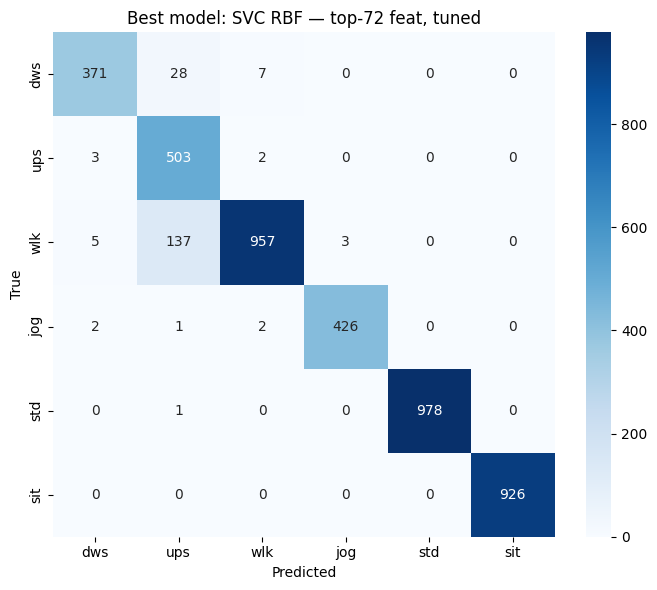

In [48]:
_pred_lookup = {
    'RF — 96 feat, default':          y_pred_rf,
    'RF — 218 feat, default':         y_pred_rf_ext,
    'RF — top-72 feat, default':      y_pred_rf_topk,
    'RF — top-72 feat, tuned':        y_pred_rf_tuned,
    'LinearSVC — 218 feat, default':  y_pred_lsvc_ext,
    'LinearSVC — top-72 feat, tuned': y_pred_lsvc_tuned,
    'SVC RBF — 218 feat, default':    y_pred_svc_rbf_ext,
    'SVC RBF — top-72 feat, default': y_pred_svc_topk,
    'SVC RBF — top-72 feat, tuned':   y_pred_svc_tuned,
}
best_name = final_df.index[0]  # final_df is sorted descending by Macro-F1
cm_best = confusion_matrix(y_test, _pred_lookup[best_name])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACT_LABELS, yticklabels=ACT_LABELS, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Best model: {best_name}')
plt.tight_layout()
plt.show()